                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Total reviews: 50000
Training shape: (25000, 100)
Testing shape: (25000, 100)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 100, 32)             │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_3                  │ (None, 100, 32)             │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 168,353 (657.63 KB)

 Trainable params: 168,353 (657.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5831 - loss: 0.6944 - val_accuracy: 0.7902 - val_loss: 0.5027
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7866 - loss: 0.4873 - val_accuracy: 0.7920 - val_loss: 0.4454
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8204 - loss: 0.4318 - val_accuracy: 0.8256 - val_loss: 0.4136
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8374 - loss: 0.3981 - val_accuracy: 0.8386 - val_loss: 0.3832
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8529 - loss: 0.3683 - val_accuracy: 0.8268 - val_loss: 0.3970
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8628 - loss: 0.3546 - val_accuracy: 0.7792 - val_loss: 0.5034
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8605 - loss: 0.3601 - val_accuracy: 0.8138 - val_loss: 0.4079
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8695 - loss: 0.3317 - 

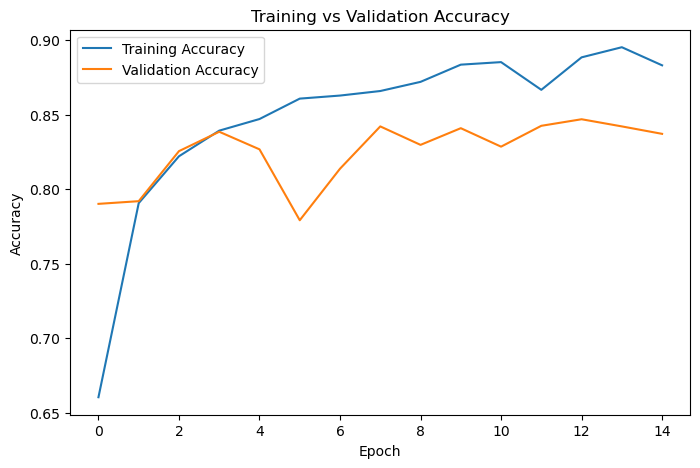

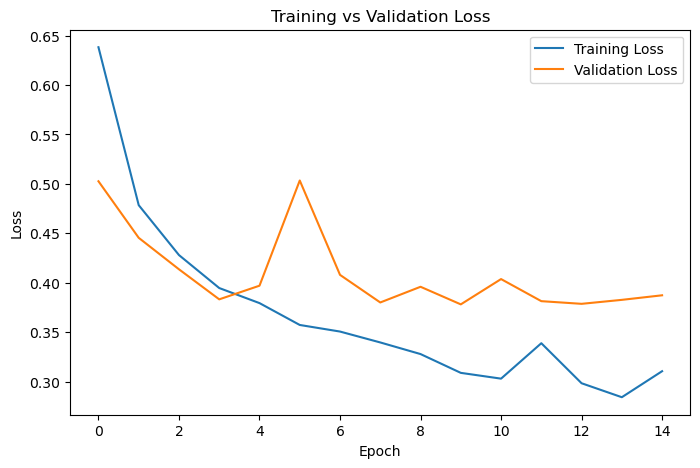

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8400 - loss: 0.3816
Final Test Accuracy: 84.00%
Final Test Loss: 0.382065087556839
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


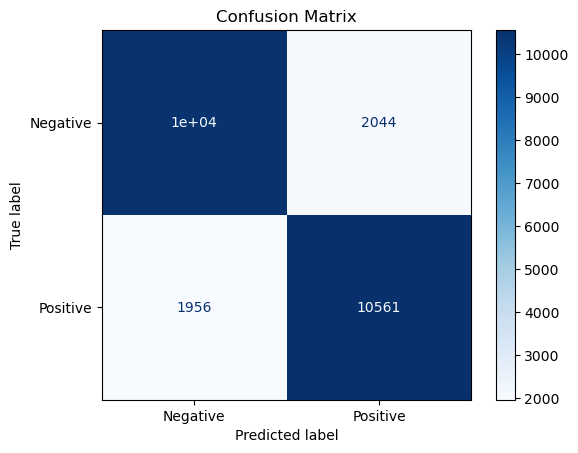

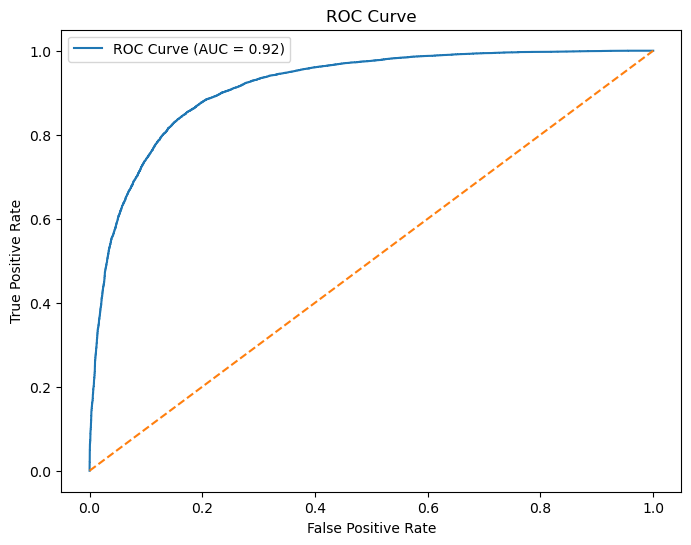

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# ---------------------------------
# 1. Load Dataset
# ---------------------------------

data = pd.read_csv(r"C:\Users\23adsb49\Downloads\IMDB Dataset.csv\IMDB Dataset.csv")

print(data.head())
print("Total reviews:", len(data))

# Convert labels
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

# ---------------------------------
# 2. Train-Test Split
# ---------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    data['review'],
    data['sentiment'],
    test_size=0.5,
    random_state=42
)

# ---------------------------------
# 3. Tokenization
# ---------------------------------

vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

# ---------------------------------
# 4. Build Model
# ---------------------------------

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32))

model.add(SpatialDropout1D(0.5))

model.add(LSTM(
    32,
    dropout=0.3,
    recurrent_dropout=0.3,
    kernel_regularizer=l2(0.001)
))

model.add(Dense(1, activation='sigmoid'))

model.build(input_shape=(None, max_len))

model.summary()

# ---------------------------------
# 5. Compile Model
# ---------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------
# 6. Early Stopping
# ---------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ---------------------------------
# 7. Train Model (100 Epochs)
# ---------------------------------

history = model.fit(
    X_train_pad,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# ---------------------------------
# 8. Accuracy Plot
# ---------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

# ---------------------------------
# 9. Loss Plot
# ---------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

# ---------------------------------
# 10. Evaluate Model
# ---------------------------------

test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Final Test Accuracy: {:.2f}%".format(test_accuracy*100))
print("Final Test Loss:", test_loss)

# ---------------------------------
# 11. Predictions
# ---------------------------------

y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int)

# ---------------------------------
# 12. Confusion Matrix
# ---------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

# ---------------------------------
# 13. ROC Curve
# ---------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()/